<a href="https://colab.research.google.com/github/lim0119/-2025-3-2-PJ/blob/main/label_%EB%B9%84%EC%9C%A8_%ED%99%95%EC%9D%B8(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# 1. CSV 파일 로드
file_path = 'train_index.csv'
df = pd.read_csv(file_path)

# 라벨 비율 계산
label_column_name = 'label'

label_counts_percent = (
    df[label_column_name]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .astype(str) + '%'
)

# 라벨별 비율
print(f"--- '{label_column_name}' 열의 라벨 비율 ---")
print(label_counts_percent)

# 비율 + 개수
label_counts = df[label_column_name].value_counts()
combined_results = pd.concat([label_counts, label_counts_percent], axis=1, keys=['Count', 'Percentage'])

print("\n--- 라벨 개수와 비율 ---")
print(combined_results)

--- 'label' 열의 라벨 비율 ---
label
0    59.89%
1    40.11%
Name: proportion, dtype: object

--- 라벨 개수와 비율 ---
       Count Percentage
label                  
0        324     59.89%
1        217     40.11%


/tmp/ipython-input-3759993002.py:95: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3759993002.py:95: UserWarning: Glyph 48296 (\N{HANGUL SYLLABLE BEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3759993002.py:95: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3759993002.py:95: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3759993002.py:95: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3759993002.py:95: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3759993002.py:95: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tm

 총 541개의 샘플을 불러왔습니다.
 고유 라벨 개수: 2

 라벨 분포:
 Label  Count  Ratio (%)
     0    324      59.89
     1    217      40.11


/tmp/ipython-input-3759993002.py:105: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.savefig(plot_path, dpi=300, bbox_inches="tight")
/tmp/ipython-input-3759993002.py:105: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.savefig(plot_path, dpi=300, bbox_inches="tight")
/tmp/ipython-input-3759993002.py:105: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.savefig(plot_path, dpi=300, bbox_inches="tight")
/tmp/ipython-input-3759993002.py:105: UserWarning: Glyph 48296 (\N{HANGUL SYLLABLE BEL}) missing from font(s) DejaVu Sans.
  plt.savefig(plot_path, dpi=300, bbox_inches="tight")
/tmp/ipython-input-3759993002.py:105: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.savefig(plot_path, dpi=300, bbox_inches="tight")
/tmp/ipython-input-3759993002.py:105: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) Dej


 그래프 저장 완료 → label_analysis/label_distribution_20251111_051923.png
 통계 CSV 저장 완료 → label_analysis/label_stats_20251111_051923.csv


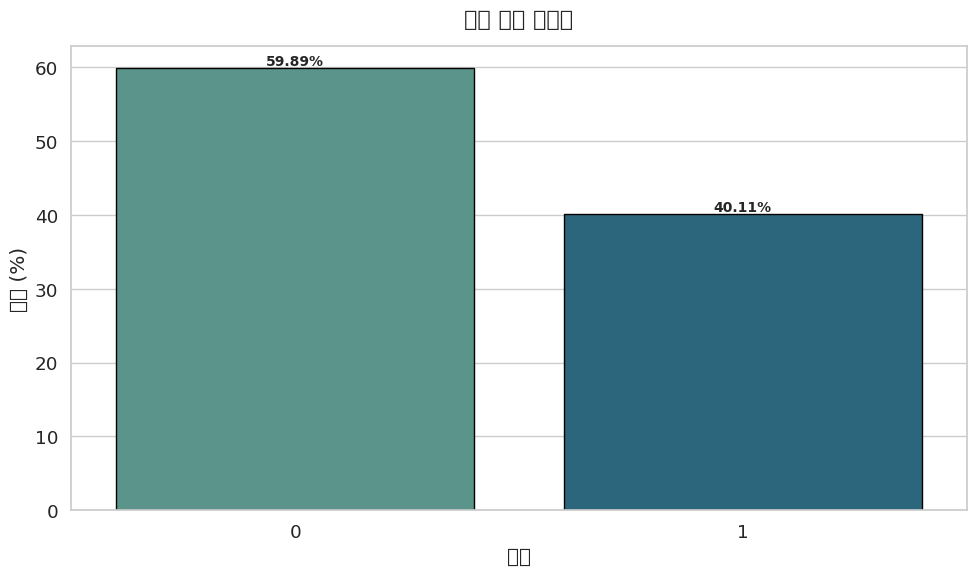

In [4]:
# 나눔고딕 폰트 설치(Colab용)
!sudo apt-get install -y fonts-nanum > /dev/null
!sudo fc-cache -fv > /dev/null
!rm -rf ~/.cache/matplotlib

# Matplotlib 한글 설정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

#  라벨 분포 분석 코드
import pandas as pd
import seaborn as sns
import os
from datetime import datetime

def analyze_label_distribution(
    csv_path: str,
    label_col: str = "label",
    save_plot: bool = True,
    output_dir: str = "label_analysis",
):
    """
    CSV 파일에서 라벨 분포를 분석하고 시각화하는 함수

    Parameters
    ----------
    csv_path : str
        라벨 정보가 포함된 CSV 파일 경로
    label_col : str, default='label'
        라벨 정보가 들어있는 열(column) 이름
    save_plot : bool, default=True
        분석 결과 그래프를 파일로 저장할지 여부
    output_dir : str, default='label_analysis'
        결과 파일(그래프, 통계 CSV)을 저장할 폴더 이름
    """

    # CSV 파일 불러오기
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f" 파일을 찾을 수 없습니다: {csv_path}")

    df = pd.read_csv(csv_path)
    if label_col not in df.columns:
        raise ValueError(f" '{label_col}' 컬럼이 CSV에 존재하지 않습니다.")

    print(f" 총 {len(df):,}개의 샘플을 불러왔습니다.")
    print(f" 고유 라벨 개수: {df[label_col].nunique()}")


    # 라벨별 개수 및 비율 계산
    label_stats = (
        df[label_col]
        .value_counts(normalize=False)
        .rename_axis("Label")
        .reset_index(name="Count")
        .sort_values("Label")
    )

    # 비율(%) 계산
    label_stats["Ratio (%)"] = (label_stats["Count"] / len(df) * 100).round(2)

    # 콘솔 출력
    print("\n 라벨 분포:")
    print(label_stats.to_string(index=False))

    # 라벨 분포 시각화
    sns.set(style="whitegrid", font="NanumGothic", font_scale=1.2)
    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        data=label_stats,
        x="Label",
        y="Ratio (%)",
        hue="Label",
        legend=False,
        palette="crest",
        edgecolor="black"
    )

    plt.title("라벨 분포 시각화", fontsize=16, weight="bold", pad=15)
    plt.ylabel("비율 (%)")
    plt.xlabel("라벨")

    # 막대 위에 비율 값 표시
    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.2f}%",
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha="center", va="bottom",
            fontsize=10, weight="bold"
        )

    plt.tight_layout()

    #  결과 저장
    if save_plot:
        os.makedirs(output_dir, exist_ok=True)
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

        plot_path = os.path.join(output_dir, f"label_distribution_{timestamp}.png")
        csv_path_out = os.path.join(output_dir, f"label_stats_{timestamp}.csv")

        plt.savefig(plot_path, dpi=300, bbox_inches="tight")
        label_stats.to_csv(csv_path_out, index=False, encoding="utf-8-sig")

        print(f"\n 그래프 저장 완료 → {plot_path}")
        print(f" 통계 CSV 저장 완료 → {csv_path_out}")

    plt.show()
    return label_stats


#  ex 실행 코드
if __name__ == "__main__":
    analyze_label_distribution(
        csv_path="train_index.csv",   # CSV 파일 경로
        label_col="label"     # 라벨 컬럼 이름
    )


고유 라벨 개수는 0,1로 2개가 존재


label 0:526개(58.44%)
label 1: 374개(41.56%)


=> 0 클래스가 약간 더 맣지만 크게 불균형한 수준은 아님


